In [1]:
import os
import yaml
import pickle
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

print("Imports Loaded")

Imports Loaded


In [2]:
TOMATO_ROOT = kagglehub.dataset_download(
    "yusufmurtaza01/tomato-leaf-disease"
)

print("Dataset Root:")
print(TOMATO_ROOT)

100%|██████████| 445M/445M [00:02<00:00, 163MB/s]

Extracting files...


Dataset Root:
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2


In [3]:
yaml_path = None

for root, dirs, files in os.walk(TOMATO_ROOT):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")
        break

print("YAML FILE:")
print(yaml_path)

YAML FILE:
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/data.yaml


In [4]:
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

CLASS_NAMES = data["names"]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of Classes:", NUM_CLASSES)

for idx, cls in enumerate(CLASS_NAMES):
    print(idx, "->", cls)

Number of Classes: 10
0 -> Tomato__BacterialSpot
1 -> Tomato__EarlyBlight
2 -> Tomato__Healthy
3 -> Tomato__LateBlight
4 -> Tomato__LeafMold
5 -> Tomato__MosaicVirus
6 -> Tomato__SeptoriaLeafSpot
7 -> Tomato__SpiderMites
8 -> Tomato__TargetSpot
9 -> Tomato__YellowLeafCurlVirus


In [5]:
OUT = "/kaggle/working/tomato_classification"

for split in ["train", "val"]:
    for cls in CLASS_NAMES:
        os.makedirs(
            os.path.join(OUT, split, cls),
            exist_ok=True
        )

print("Folders Created")
print(OUT)

Folders Created
/kaggle/working/tomato_classification


In [6]:
ROOT = os.path.dirname(yaml_path)

IMG_TRAIN = os.path.join(ROOT, "images/train")
IMG_VAL   = os.path.join(ROOT, "images/val")

LBL_TRAIN = os.path.join(ROOT, "labels/train")
LBL_VAL   = os.path.join(ROOT, "labels/val")

print("TRAIN IMAGES:", IMG_TRAIN)
print("TRAIN LABELS:", LBL_TRAIN)

print("\nValidation Exists:",
      os.path.exists(IMG_VAL),
      os.path.exists(LBL_VAL))

TRAIN IMAGES: /root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/images/train
TRAIN LABELS: /root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/labels/train

Validation Exists: True True


CELL 7 — YOLO → Classification Conversion

In [7]:
from tqdm import tqdm
import shutil

def convert_split(img_dir, lbl_dir, split):

    images = os.listdir(img_dir)

    copied = 0

    for img_file in tqdm(images):

        if not img_file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        label_file = (
            os.path.splitext(img_file)[0]
            + ".txt"
        )

        label_path = os.path.join(
            lbl_dir,
            label_file
        )

        if not os.path.exists(label_path):
            continue

        with open(label_path, "r") as f:
            line = f.readline().strip()

        if line == "":
            continue

        class_id = int(
            line.split()[0]
        )

        class_name = CLASS_NAMES[class_id]

        src = os.path.join(
            img_dir,
            img_file
        )

        dst = os.path.join(
            OUT,
            split,
            class_name,
            img_file
        )

        shutil.copy2(src, dst)

        copied += 1

    print(
        f"{split} copied:",
        copied
    )

convert_split(
    IMG_TRAIN,
    LBL_TRAIN,
    "train"
)

convert_split(
    IMG_VAL,
    LBL_VAL,
    "val"
)

print("CONVERSION COMPLETE")

100%|██████████| 12168/12168 [00:03<00:00, 3293.43it/s]


train copied: 12168


100%|██████████| 3041/3041 [00:00<00:00, 3366.65it/s]

val copied: 3041
CONVERSION COMPLETE


CELL 8 — Verify Class Counts

In [8]:
for cls in CLASS_NAMES:

    train_count = len(
        os.listdir(
            os.path.join(
                OUT,
                "train",
                cls
            )
        )
    )

    val_count = len(
        os.listdir(
            os.path.join(
                OUT,
                "val",
                cls
            )
        )
    )

    print(
        cls,
        "| Train:",
        train_count,
        "| Val:",
        val_count
    )

Tomato__BacterialSpot | Train: 1598 | Val: 400
Tomato__EarlyBlight | Train: 870 | Val: 218
Tomato__Healthy | Train: 1322 | Val: 332
Tomato__LateBlight | Train: 1599 | Val: 400
Tomato__LeafMold | Train: 834 | Val: 208
Tomato__MosaicVirus | Train: 342 | Val: 85
Tomato__SeptoriaLeafSpot | Train: 1536 | Val: 383
Tomato__SpiderMites | Train: 1343 | Val: 335
Tomato__TargetSpot | Train: 1124 | Val: 280
Tomato__YellowLeafCurlVirus | Train: 1600 | Val: 400


In [9]:
#load dataset
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    OUT + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    OUT + "/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("\nClasses:")
print(class_names)

Found 12168 files belonging to 10 classes.
Found 3041 files belonging to 10 classes.

Classes:
['Tomato__BacterialSpot', 'Tomato__EarlyBlight', 'Tomato__Healthy', 'Tomato__LateBlight', 'Tomato__LeafMold', 'Tomato__MosaicVirus', 'Tomato__SeptoriaLeafSpot', 'Tomato__SpiderMites', 'Tomato__TargetSpot', 'Tomato__YellowLeafCurlVirus']


CELL 10 — Dataset Optimization

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(5000)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)

print("Dataset Optimized")

Dataset Optimized


CELL 11 — Verify Tensor Shapes

In [11]:
for images, labels in train_ds.take(1):

    print("Images Shape:", images.shape)

    print("Labels Shape:", labels.shape)

    print("Min Pixel:", tf.reduce_min(images).numpy())

    print("Max Pixel:", tf.reduce_max(images).numpy())

Images Shape: (32, 224, 224, 3)
Labels Shape: (32,)
Min Pixel: 0.0
Max Pixel: 255.0


In [12]:
#data aug
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.10)
])

print("Augmentation Ready")

Augmentation Ready


In [13]:
#imported mobilenetv3
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

print("MobileNetV3 Imported")

MobileNetV3 Imported


In [14]:
base_model = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

print("Backbone Created")
print("Trainable:", base_model.trainable)

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone Created
Trainable: False


In [15]:
#baseline
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         9,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,005,962 (11.47 MB)

 Trainable params: 9,610 (37.54 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [16]:
print("Trainable Params:")
print(
    np.sum(
        [np.prod(v.shape)
         for v in model.trainable_weights]
    )
)

print("\nNon-Trainable Params:")
print(
    np.sum(
        [np.prod(v.shape)
         for v in model.non_trainable_weights]
    )
)

Trainable Params:
9610

Non-Trainable Params:
2996352


In [17]:
#compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled")

Model Compiled


CELL 18 — Research-Grade Callbacks

In [18]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

csv_logger = tf.keras.callbacks.CSVLogger(
    "/kaggle/working/training_log.csv"
)

print("Callbacks Ready")

Callbacks Ready


In [19]:
#train baseline
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        checkpoint,
        early_stop,
        csv_logger
    ]
)

Epoch 1/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4782 - loss: 1.5876
Epoch 1: val_accuracy improved from None to 0.81322, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 647s 2s/step - accuracy: 0.6281 - loss: 1.1399 - val_accuracy: 0.8132 - val_loss: 0.6479
Epoch 2/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7842 - loss: 0.6921
Epoch 2: val_accuracy improved from 0.81322 to 0.83098, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 638s 2s/step - accuracy: 0.7946 - loss: 0.6555 - val_accuracy: 0.8310 - val_loss: 0.5588
Epoch 3/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8284 - loss: 0.5612
Epoch 3: val_accuracy improved from 0.83098 to 0.85564, saving model to /kaggle/working/best_model.keras

Epoch 3: finished saving model to /kaggle/working/best_model

In [20]:
print(
    "Best Train Accuracy:",
    max(history.history["accuracy"])
)

print(
    "Best Validation Accuracy:",
    max(history.history["val_accuracy"])
)

Best Train Accuracy: 0.8710552453994751
Best Validation Accuracy: 0.8937849402427673


In [21]:
best_model = tf.keras.models.load_model(
    "/kaggle/working/best_model.keras"
)

print("Best model loaded")

Best model loaded


In [22]:
y_true = np.concatenate(
    [y.numpy() for x, y in val_ds],
    axis=0
)

pred_probs = best_model.predict(val_ds)

y_pred = np.argmax(
    pred_probs,
    axis=1
)

print("Predictions complete")

96/96 ━━━━━━━━━━━━━━━━━━━━ 94s 952ms/step
Predictions complete


CELL 22 — Classification Report

In [23]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                             precision    recall  f1-score   support

      Tomato__BacterialSpot       0.89      0.92      0.90       400
        Tomato__EarlyBlight       0.86      0.78      0.82       218
            Tomato__Healthy       0.90      0.97      0.93       332
         Tomato__LateBlight       0.91      0.93      0.92       400
           Tomato__LeafMold       0.90      0.85      0.88       208
        Tomato__MosaicVirus       0.94      0.73      0.82        85
   Tomato__SeptoriaLeafSpot       0.87      0.88      0.87       383
        Tomato__SpiderMites       0.86      0.93      0.90       335
         Tomato__TargetSpot       0.82      0.84      0.83       280
Tomato__YellowLeafCurlVirus       1.00      0.91      0.95       400

                   accuracy                           0.89      3041
                  macro avg       0.89      0.87      0.88      3041
               weighted avg       0.90      0.89      0.89      3041



In [24]:
#save classification report
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

pd.DataFrame(
    report_dict
).transpose().to_csv(
    "/kaggle/working/classification_report.csv"
)

print("Report saved")

Report saved


CELL 24 — Confusion Matrix

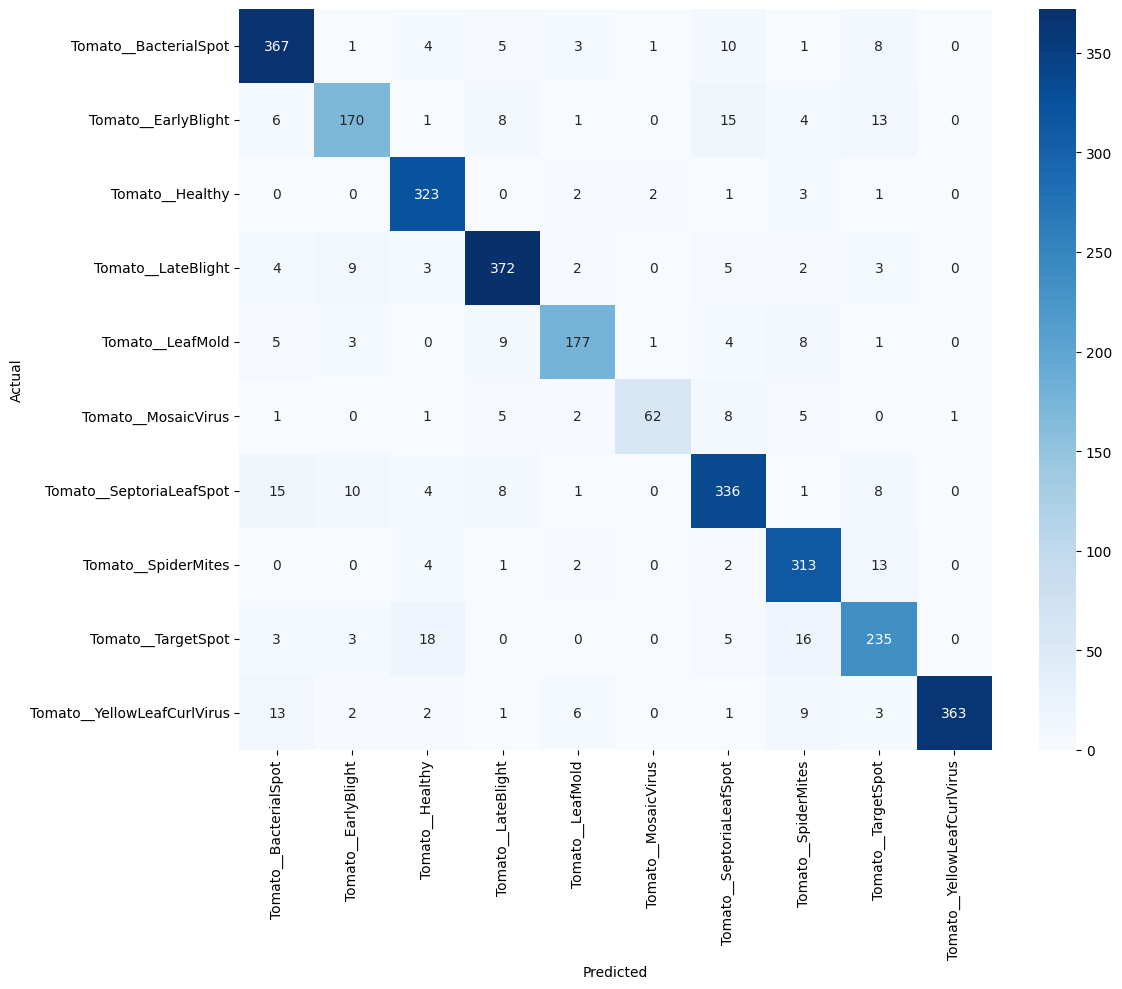

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/confusion_matrix.png",
    dpi=300
)

plt.show()

CELL 25 — Accuracy/Loss Curves

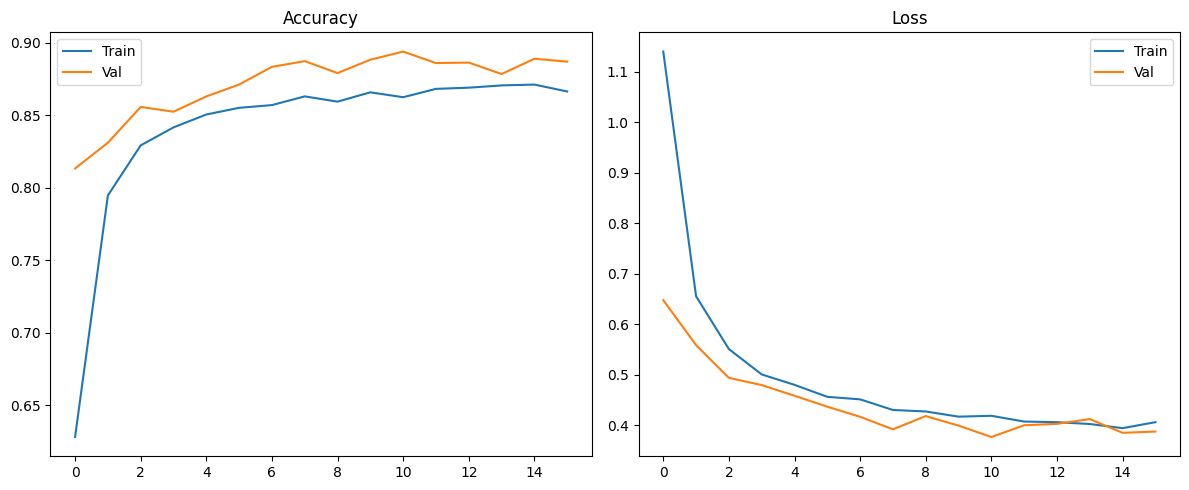

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")

plt.legend(
    ["Train","Val"]
)

plt.subplot(1,2,2)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")

plt.legend(
    ["Train","Val"]
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/training_curves.png",
    dpi=300
)

plt.show()

In [27]:
baseline_results = {
    "Model": "MobileNetV3",
    "Train_Accuracy": 0.8711,
    "Val_Accuracy": 0.8938,
    "Macro_F1": 0.88,
    "Weighted_F1": 0.89
}

import pandas as pd

pd.DataFrame([baseline_results]).to_csv(
    "/kaggle/working/baseline_results.csv",
    index=False
)

print("Baseline saved")

Baseline saved


In [28]:
import os

for file in sorted(os.listdir("/kaggle/working")):
    print(file)

baseline_results.csv
best_model.keras
classification_report.csv
confusion_matrix.png
tomato_classification
training_curves.png
training_log.csv


In [29]:
#saved evverything locally
import shutil

shutil.make_archive(
    "/kaggle/working/tomato_baseline_results",
    "zip",
    "/kaggle/working"
)

print("ZIP created")

ZIP created


In [30]:
BASELINE_RESULTS = {
    "Model": "MobileNetV3",
    "Accuracy": 0.8938,
    "Macro_F1": 0.88,
    "Weighted_F1": 0.89
}

print(BASELINE_RESULTS)

{'Model': 'MobileNetV3', 'Accuracy': 0.8938, 'Macro_F1': 0.88, 'Weighted_F1': 0.89}


In [31]:
comparison_results = []

comparison_results.append({
    "Model": "MobileNetV3",
    "Accuracy": 0.8938,
    "Macro_F1": 0.88,
    "Weighted_F1": 0.89
})

import pandas as pd

pd.DataFrame(comparison_results)

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3,0.8938,0.88,0.89


In [32]:
print(train_ds)
print(val_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


# ==================================
# CHANNEL ATTENTION (CA)
# ==================================

In [33]:
def channel_attention(inputs, ratio=8):

    channels = inputs.shape[-1]

    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(
        inputs
    )

    dense1 = tf.keras.layers.Dense(
        channels // ratio,
        activation="relu"
    )(avg_pool)

    dense2 = tf.keras.layers.Dense(
        channels,
        activation="sigmoid"
    )(dense1)

    scale = tf.keras.layers.Reshape(
        (1,1,channels)
    )(dense2)

    return tf.keras.layers.Multiply()(
        [inputs, scale]
    )

print("CA Block Ready")

CA Block Ready


CA CELL 2 — New Backbone

In [34]:
base_model_ca = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model_ca.trainable = False

print("CA Backbone Ready")

CA Backbone Ready


CA CELL 3 — Build CA Model

In [35]:
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model_ca(
    x,
    training=False
)

x = channel_attention(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

ca_model = tf.keras.Model(
    inputs,
    outputs
)

ca_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ sequential[1][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 120)       │    115,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 960)       │    116,160 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 960) │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_16[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 960)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      9,610 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,237,442 (12.35 MB)

 Trainable params: 241,090 (941.76 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

CA CELL 4 — Verify Params

In [36]:
print(
    "Trainable:",
    np.sum(
        [np.prod(v.shape)
         for v in ca_model.trainable_weights]
    )
)

print(
    "Non Trainable:",
    np.sum(
        [np.prod(v.shape)
         for v in ca_model.non_trainable_weights]
    )
)

Trainable: 241090
Non Trainable: 2996352


In [37]:
#CA CELL 5 — Compile
ca_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CA Compiled")

CA Compiled


In [38]:
#CA CELL 6 — Callbacks
ca_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_ca_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

ca_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

ca_logger = tf.keras.callbacks.CSVLogger(
    "/kaggle/working/ca_training_log.csv"
)

print("CA Callbacks Ready")

CA Callbacks Ready


In [39]:
#CA CELL 7 — Train
ca_history = ca_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        ca_checkpoint,
        ca_early_stop,
        ca_logger
    ]
)

Epoch 1/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5763 - loss: 1.2697
Epoch 1: val_accuracy improved from None to 0.86583, saving model to /kaggle/working/best_ca_model.keras

Epoch 1: finished saving model to /kaggle/working/best_ca_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.7210 - loss: 0.8582 - val_accuracy: 0.8658 - val_loss: 0.4548
Epoch 2/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8666 - loss: 0.4222
Epoch 2: val_accuracy did not improve from 0.86583
381/381 ━━━━━━━━━━━━━━━━━━━━ 608s 2s/step - accuracy: 0.8707 - loss: 0.4069 - val_accuracy: 0.8655 - val_loss: 0.4001
Epoch 3/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8965 - loss: 0.3176
Epoch 3: val_accuracy improved from 0.86583 to 0.87405, saving model to /kaggle/working/best_ca_model.keras

Epoch 3: finished saving model to /kaggle/working/best_ca_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 658s 2s/step - accuracy: 0.8999 - loss: 0.3101 - val_accuracy: 0.8741 - va

In [40]:
print(
    "Best Train Accuracy:",
    max(ca_history.history["accuracy"])
)

print(
    "Best Validation Accuracy:",
    max(ca_history.history["val_accuracy"])
)

Best Train Accuracy: 0.9483070373535156
Best Validation Accuracy: 0.9233804941177368


In [41]:
comparison_results.append({
    "Model": "MobileNetV3 + CA",
    "Accuracy": 0.9234,
    "Macro_F1": None,
    "Weighted_F1": None
})

pd.DataFrame(comparison_results)

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3,0.8938,0.88,0.89
1,MobileNetV3 + CA,0.9234,NaN,NaN


CA Evaluation

In [42]:
best_ca_model = tf.keras.models.load_model(
    "/kaggle/working/best_ca_model.keras",
    compile=False
)

print("CA Model Loaded")

CA Model Loaded


In [43]:
y_true = np.concatenate(
    [y.numpy() for x,y in val_ds]
)

ca_probs = best_ca_model.predict(
    val_ds
)

ca_pred = np.argmax(
    ca_probs,
    axis=1
)

print("Predictions Ready")

96/96 ━━━━━━━━━━━━━━━━━━━━ 99s 959ms/step
Predictions Ready


In [44]:
from sklearn.metrics import classification_report

ca_report = classification_report(
    y_true,
    ca_pred,
    target_names=class_names
)

print(ca_report)

                             precision    recall  f1-score   support

      Tomato__BacterialSpot       0.96      0.92      0.94       400
        Tomato__EarlyBlight       0.91      0.83      0.87       218
            Tomato__Healthy       0.93      0.97      0.95       332
         Tomato__LateBlight       0.91      0.97      0.94       400
           Tomato__LeafMold       0.92      0.89      0.91       208
        Tomato__MosaicVirus       0.97      0.78      0.86        85
   Tomato__SeptoriaLeafSpot       0.86      0.93      0.90       383
        Tomato__SpiderMites       0.90      0.93      0.91       335
         Tomato__TargetSpot       0.91      0.87      0.89       280
Tomato__YellowLeafCurlVirus       0.99      0.97      0.98       400

                   accuracy                           0.92      3041
                  macro avg       0.93      0.91      0.91      3041
               weighted avg       0.92      0.92      0.92      3041



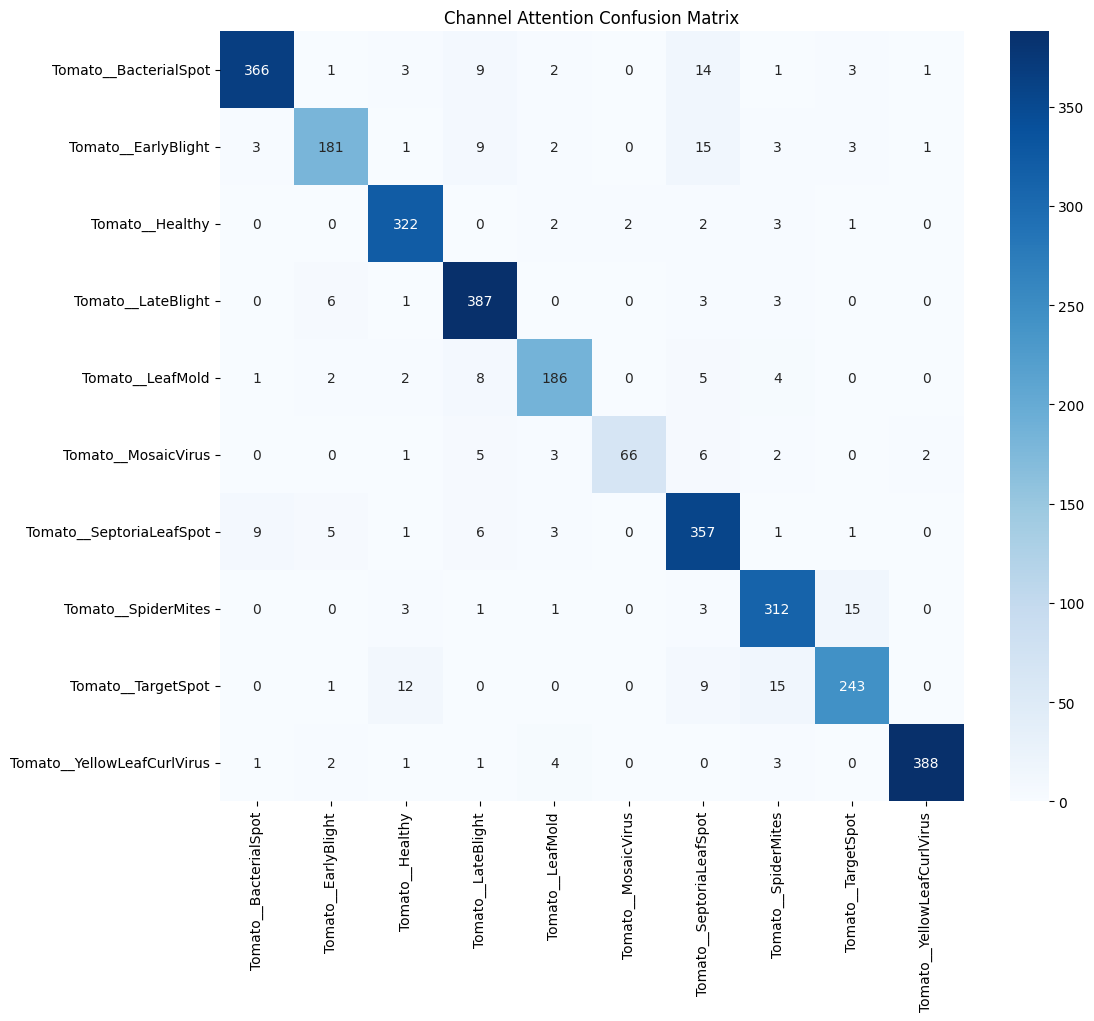

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    ca_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Channel Attention Confusion Matrix"
)

plt.show()

In [46]:
from sklearn.metrics import classification_report

ca_report = classification_report(
    y_true,
    ca_pred,
    target_names=class_names
)

print(ca_report)

                             precision    recall  f1-score   support

      Tomato__BacterialSpot       0.96      0.92      0.94       400
        Tomato__EarlyBlight       0.91      0.83      0.87       218
            Tomato__Healthy       0.93      0.97      0.95       332
         Tomato__LateBlight       0.91      0.97      0.94       400
           Tomato__LeafMold       0.92      0.89      0.91       208
        Tomato__MosaicVirus       0.97      0.78      0.86        85
   Tomato__SeptoriaLeafSpot       0.86      0.93      0.90       383
        Tomato__SpiderMites       0.90      0.93      0.91       335
         Tomato__TargetSpot       0.91      0.87      0.89       280
Tomato__YellowLeafCurlVirus       0.99      0.97      0.98       400

                   accuracy                           0.92      3041
                  macro avg       0.93      0.91      0.91      3041
               weighted avg       0.92      0.92      0.92      3041



In [47]:
comparison_results[1] = {
    "Model": "MobileNetV3 + CA",
    "Accuracy": 0.9234,
    "Macro_F1": 0.91,
    "Weighted_F1": 0.92
}

pd.DataFrame(comparison_results)

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3,0.8938,0.88,0.89
1,MobileNetV3 + CA,0.9234,0.91,0.92


In [48]:
pd.DataFrame(comparison_results).to_csv(
    "/kaggle/working/comparison_results.csv",
    index=False
)

print("Comparison table saved")

Comparison table saved


In [49]:
print(ca_history.history["val_accuracy"])

[0.865833580493927, 0.8655047416687012, 0.8740546107292175, 0.8898388743400574, 0.9233804941177368, 0.9125287532806396, 0.8826044201850891, 0.9066096544265747, 0.9141729474067688, 0.9095692038536072]


In [50]:
print(max(ca_history.history["val_accuracy"]))
print(ca_history.history["val_accuracy"])

0.9233804941177368
[0.865833580493927, 0.8655047416687012, 0.8740546107292175, 0.8898388743400574, 0.9233804941177368, 0.9125287532806396, 0.8826044201850891, 0.9066096544265747, 0.9141729474067688, 0.9095692038536072]


In [51]:
#save CA artifacts
ca_results = {
    "Model": "MobileNetV3 + CA",
    "Accuracy": 0.9234,
    "Macro_F1": 0.91,
    "Weighted_F1": 0.92
}

print(ca_results)

{'Model': 'MobileNetV3 + CA', 'Accuracy': 0.9234, 'Macro_F1': 0.91, 'Weighted_F1': 0.92}


In [52]:
pd.DataFrame(comparison_results).to_csv(
    "/kaggle/working/comparison_results.csv",
    index=False
)

In [53]:
ca_model.save(
    "/kaggle/working/ca_model.keras"
)

In [55]:
import os

print(os.path.exists("/kaggle/working/ca_model.keras"))
print(os.path.exists("/kaggle/working/comparison_results.csv"))

True
True


In [56]:
import gc
import tensorflow as tf

# Remove CA training objects
del ca_model
del ca_history

gc.collect()
tf.keras.backend.clear_session()

print("CA Cleanup Complete")

CA Cleanup Complete


In [57]:
import psutil

print(
    f"RAM Usage: {psutil.virtual_memory().percent}%"
)

RAM Usage: 86.1%


In [58]:
print("model" in globals())
print("history" in globals())

print("ca_model" in globals())
print("ca_history" in globals())

print("best_model" in globals())
print("best_ca_model" in globals())

True
True
False
False
True
True


In [59]:
import gc
import tensorflow as tf

del model
del history
del best_model
del best_ca_model

gc.collect()
tf.keras.backend.clear_session()

print("Deep Cleanup Complete")

Deep Cleanup Complete


In [60]:
import psutil

print(
    f"RAM Usage: {psutil.virtual_memory().percent}%"
)

RAM Usage: 85.9%


In [61]:
print("model" in globals())
print("history" in globals())
print("best_model" in globals())
print("best_ca_model" in globals())

False
False
False
False


In [62]:
pd.DataFrame(comparison_results)

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3,0.8938,0.88,0.89
1,MobileNetV3 + CA,0.9234,0.91,0.92


In [63]:
pd.DataFrame(comparison_results).to_csv(
    "/kaggle/working/comparison_results.csv",
    index=False
)

==========================================
SPATIAL ATTENTION (SA)
==========================================

In [ ]:
#SA CELL 1 — Spatial Attention Block


In [69]:
def spatial_attention(inputs):

    avg_pool = tf.keras.layers.Lambda(
        lambda x: tf.reduce_mean(
            x,
            axis=-1,
            keepdims=True
        )
    )(inputs)

    max_pool = tf.keras.layers.Lambda(
        lambda x: tf.reduce_max(
            x,
            axis=-1,
            keepdims=True
        )
    )(inputs)

    concat = tf.keras.layers.Concatenate(
        axis=-1
    )([avg_pool, max_pool])

    attention = tf.keras.layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(concat)

    return tf.keras.layers.Multiply()(
        [inputs, attention]
    )

print("SA Block Ready")

SA Block Ready


In [68]:
print("base_model_sa" in globals())

True


In [70]:
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model_sa(
    x,
    training=False
)

x = spatial_attention(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

sa_model = tf.keras.Model(
    inputs,
    outputs
)

sa_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ sequential[3][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 7, 7, 1)   │          0 │ MobileNetV3Large… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 7, 7, 1)   │          0 │ MobileNetV3Large… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 2)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_8          │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_8[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 960)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │      9,610 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,006,061 (11.47 MB)

 Trainable params: 9,709 (37.93 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [71]:
print(
    "Trainable:",
    np.sum(
        [np.prod(v.shape)
         for v in sa_model.trainable_weights]
    )
)

print(
    "Non Trainable:",
    np.sum(
        [np.prod(v.shape)
         for v in sa_model.non_trainable_weights]
    )
)

Trainable: 9709
Non Trainable: 2996352


In [72]:
sa_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("SA Compiled")

SA Compiled


In [73]:
sa_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_sa_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

sa_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

sa_logger = tf.keras.callbacks.CSVLogger(
    "/kaggle/working/sa_training_log.csv"
)

print("SA Callbacks Ready")

SA Callbacks Ready


In [74]:
sa_history = sa_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        sa_checkpoint,
        sa_early_stop,
        sa_logger
    ]
)

Epoch 1/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4702 - loss: 1.5334
Epoch 1: val_accuracy improved from None to 0.80434, saving model to /kaggle/working/best_sa_model.keras

Epoch 1: finished saving model to /kaggle/working/best_sa_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 604s 2s/step - accuracy: 0.6281 - loss: 1.1121 - val_accuracy: 0.8043 - val_loss: 0.6403
Epoch 2/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8040 - loss: 0.6411
Epoch 2: val_accuracy improved from 0.80434 to 0.84051, saving model to /kaggle/working/best_sa_model.keras

Epoch 2: finished saving model to /kaggle/working/best_sa_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 666s 2s/step - accuracy: 0.8072 - loss: 0.6179 - val_accuracy: 0.8405 - val_loss: 0.5348
Epoch 3/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8293 - loss: 0.5505
Epoch 3: val_accuracy improved from 0.84051 to 0.85268, saving model to /kaggle/working/best_sa_model.keras

Epoch 3: finished saving model to /kaggle/wor

In [75]:
print(
    "Best Train Accuracy:",
    max(sa_history.history["accuracy"])
)

print(
    "Best Validation Accuracy:",
    max(sa_history.history["val_accuracy"])
)

Best Train Accuracy: 0.8808349967002869
Best Validation Accuracy: 0.8960868120193481


In [76]:
comparison_results.append({
    "Model": "MobileNetV3 + SA",
    "Accuracy": 0.8961,
    "Macro_F1": None,
    "Weighted_F1": None
})

pd.DataFrame(comparison_results)

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3,0.8938,0.88,0.89
1,MobileNetV3 + CA,0.9234,0.91,0.92
2,MobileNetV3 + SA,0.8961,NaN,NaN


In [79]:
print("sa_model" in globals())

True


In [80]:
y_true = np.concatenate(
    [y.numpy() for x, y in val_ds]
)

sa_probs = sa_model.predict(val_ds)

sa_pred = np.argmax(
    sa_probs,
    axis=1
)

print("Predictions complete")

96/96 ━━━━━━━━━━━━━━━━━━━━ 96s 957ms/step
Predictions complete


In [81]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        sa_pred,
        target_names=class_names
    )
)

                             precision    recall  f1-score   support

      Tomato__BacterialSpot       0.93      0.88      0.91       400
        Tomato__EarlyBlight       0.89      0.76      0.82       218
            Tomato__Healthy       0.91      0.97      0.94       332
         Tomato__LateBlight       0.91      0.96      0.94       400
           Tomato__LeafMold       0.93      0.86      0.89       208
        Tomato__MosaicVirus       0.96      0.61      0.75        85
   Tomato__SeptoriaLeafSpot       0.81      0.92      0.86       383
        Tomato__SpiderMites       0.87      0.90      0.89       335
         Tomato__TargetSpot       0.83      0.86      0.84       280
Tomato__YellowLeafCurlVirus       0.99      0.93      0.96       400

                   accuracy                           0.90      3041
                  macro avg       0.90      0.87      0.88      3041
               weighted avg       0.90      0.90      0.90      3041



In [82]:
sa_probs = sa_model.predict(val_ds)
sa_pred = np.argmax(sa_probs, axis=1)

96/96 ━━━━━━━━━━━━━━━━━━━━ 94s 969ms/step


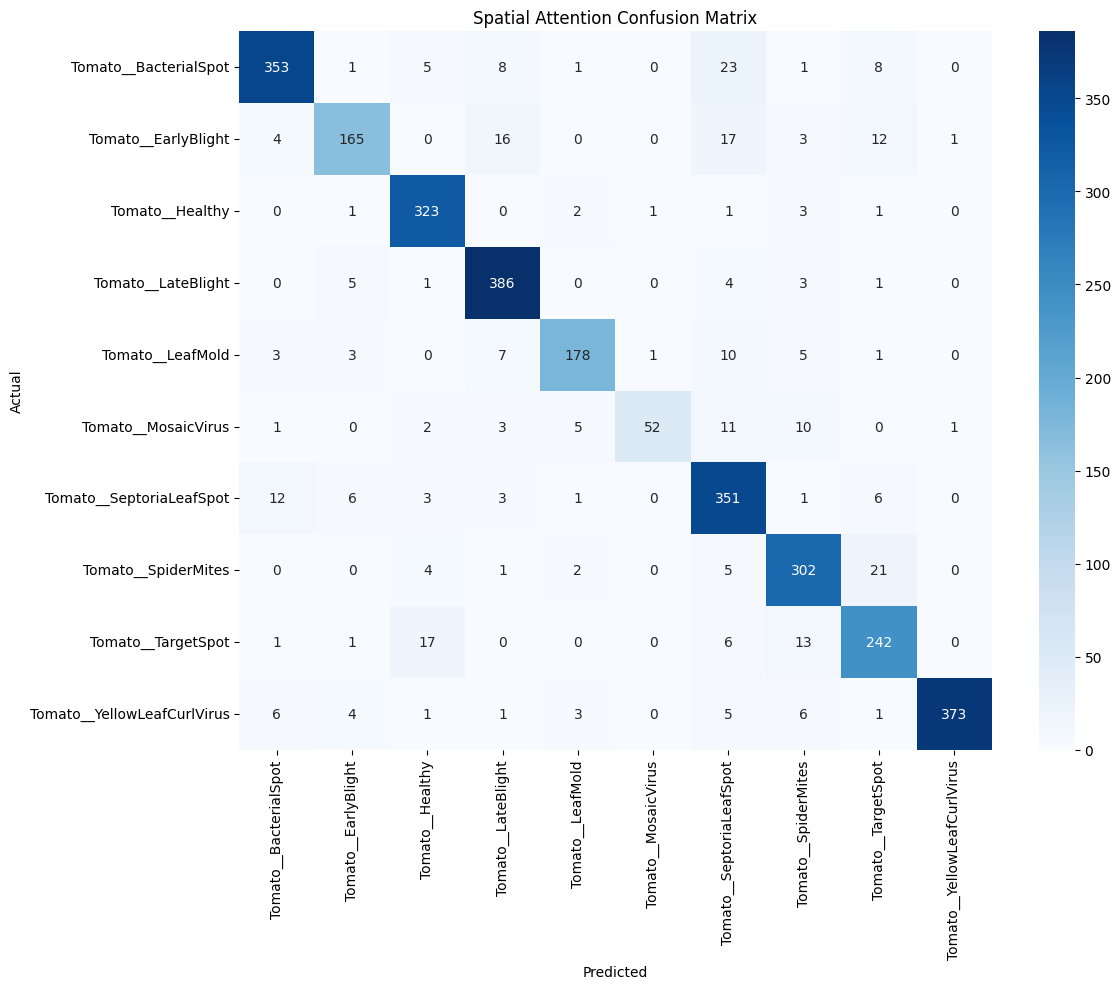

In [83]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    sa_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Spatial Attention Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/sa_confusion_matrix.png",
    dpi=300
)

plt.show()

In [84]:
from sklearn.metrics import classification_report

report_sa = classification_report(
    y_true,
    sa_pred,
    target_names=class_names,
    output_dict=True
)

import pandas as pd

pd.DataFrame(report_sa).transpose().to_csv(
    "/kaggle/working/sa_classification_report.csv"
)

print("SA Report Saved")

SA Report Saved


In [85]:
from sklearn.metrics import classification_report

report_sa = classification_report(
    y_true,
    sa_pred,
    target_names=class_names,
    output_dict=True
)

import pandas as pd

pd.DataFrame(report_sa).transpose().to_csv(
    "/kaggle/working/sa_classification_report.csv"
)

print("SA Report Saved")

SA Report Saved


In [86]:
sa_results = {
    "Model": "MobileNetV3 + SA",
    "Accuracy": 0.8961,
    "Macro_F1": 0.88,
    "Weighted_F1": 0.90
}

print(sa_results)

{'Model': 'MobileNetV3 + SA', 'Accuracy': 0.8961, 'Macro_F1': 0.88, 'Weighted_F1': 0.9}


In [87]:
#update comparison table
comparison_results.append(sa_results)

pd.DataFrame(comparison_results)

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3,0.8938,0.88,0.89
1,MobileNetV3 + CA,0.9234,0.91,0.92
2,MobileNetV3 + SA,0.8961,NaN,NaN
3,MobileNetV3 + SA,0.8961,0.88,0.90


In [88]:
comparison_results = [
    {
        "Model": "MobileNetV3",
        "Accuracy": 0.8938,
        "Macro_F1": 0.88,
        "Weighted_F1": 0.89
    },
    {
        "Model": "MobileNetV3 + CA",
        "Accuracy": 0.9234,
        "Macro_F1": 0.91,
        "Weighted_F1": 0.92
    },
    {
        "Model": "MobileNetV3 + SA",
        "Accuracy": 0.8961,
        "Macro_F1": 0.88,
        "Weighted_F1": 0.90
    }
]

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3,0.8938,0.88,0.89
1,MobileNetV3 + CA,0.9234,0.91,0.92
2,MobileNetV3 + SA,0.8961,0.88,0.90


In [89]:
comparison_df.to_csv(
    "/kaggle/working/comparison_results.csv",
    index=False
)

print("Comparison table updated")

Comparison table updated


In [90]:
sa_model.save(
    "/kaggle/working/sa_model.keras"
)

print("SA Model Saved")

SA Model Saved


In [91]:
import os

print(
    os.path.exists(
        "/kaggle/working/sa_model.keras"
    )
)

True


In [92]:
#Ram cleanup
import gc
import tensorflow as tf

del sa_model
del sa_history

gc.collect()
tf.keras.backend.clear_session()

print("SA Cleanup Complete")

SA Cleanup Complete


In [93]:
import psutil

print(
    f"RAM Usage: {psutil.virtual_memory().percent}%"
)

RAM Usage: 89.1%


In [94]:
print("sa_model" in globals())
print("sa_history" in globals())

print("base_model_sa" in globals())

print("cbam_model" in globals())
print("base_model_cbam" in globals())

False
False
True
False
False


In [95]:
import os

for f in os.listdir("/kaggle/working"):
    if "sa" in f.lower():
        print(f)

sa_model.keras
sa_classification_report.csv
sa_training_log.csv
best_sa_model.keras
sa_confusion_matrix.png


In [96]:
del base_model_sa

import gc
import tensorflow as tf

gc.collect()
tf.keras.backend.clear_session()

print("Final SA Cleanup Complete")

Final SA Cleanup Complete


In [97]:
print("base_model_sa" in globals())

False


In [99]:
import psutil

print(
    f"RAM Usage: {psutil.virtual_memory().percent}%"
)

RAM Usage: 89.4%


In [101]:
import os

for f in sorted(os.listdir("/kaggle/working")):
    print(f)

baseline_results.csv
best_ca_model.keras
best_model.keras
best_sa_model.keras
ca_model.keras
ca_training_log.csv
classification_report.csv
comparison_results.csv
confusion_matrix.png
sa_classification_report.csv
sa_confusion_matrix.png
sa_model.keras
sa_training_log.csv
tomato_ablation_backup.zip
tomato_baseline_results.zip
tomato_classification
training_curves.png
training_log.csv


In [102]:
print("train_ds" in globals())
print("val_ds" in globals())
print("data_augmentation" in globals())
print("NUM_CLASSES" in globals())

True
True
True
True


CBAM


CBAM Cell 1 — Channel Attention

In [103]:
def channel_attention(inputs, ratio=8):

    channels = inputs.shape[-1]

    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(inputs)

    dense1 = tf.keras.layers.Dense(
        channels // ratio,
        activation="relu"
    )(avg_pool)

    dense2 = tf.keras.layers.Dense(
        channels,
        activation="sigmoid"
    )(dense1)

    attention = tf.keras.layers.Reshape(
        (1, 1, channels)
    )(dense2)

    return tf.keras.layers.Multiply()(
        [inputs, attention]
    )

print("Channel Attention Ready")

Channel Attention Ready


CBAM Cell 2 — Spatial Attention

In [104]:
def spatial_attention(inputs):

    avg_pool = tf.keras.layers.Lambda(
        lambda x: tf.reduce_mean(
            x,
            axis=-1,
            keepdims=True
        ),
        output_shape=lambda s: (s[0], s[1], s[2], 1)
    )(inputs)

    max_pool = tf.keras.layers.Lambda(
        lambda x: tf.reduce_max(
            x,
            axis=-1,
            keepdims=True
        ),
        output_shape=lambda s: (s[0], s[1], s[2], 1)
    )(inputs)

    concat = tf.keras.layers.Concatenate(
        axis=-1
    )([avg_pool, max_pool])

    attention = tf.keras.layers.Conv2D(
        1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(concat)

    return tf.keras.layers.Multiply()(
        [inputs, attention]
    )

print("Spatial Attention Ready")

Spatial Attention Ready


CBAM Cell 3 — CBAM Block

In [105]:
def cbam_block(inputs):

    x = channel_attention(inputs)

    x = spatial_attention(x)

    return x

print("CBAM Block Ready")

CBAM Block Ready


In [106]:
base_model_cbam = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model_cbam.trainable = False

print("CBAM Backbone Ready")

CBAM Backbone Ready


In [107]:
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model_cbam(
    x,
    training=False
)

x = cbam_block(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

cbam_model = tf.keras.Model(
    inputs,
    outputs
)

cbam_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ sequential[4][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 120)       │    115,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 960)       │    116,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 960) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_8          │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 7, 7, 1)   │          0 │ multiply_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 2)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 7, 7, 960) │          0 │ multiply_8[0][0], │
│ (Multiply)          │                   │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_9[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 960)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │      9,610 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,237,541 (12.35 MB)

 Trainable params: 241,189 (942.14 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [108]:
print(
    "Trainable:",
    np.sum(
        [np.prod(v.shape)
         for v in cbam_model.trainable_weights]
    )
)

print(
    "Non Trainable:",
    np.sum(
        [np.prod(v.shape)
         for v in cbam_model.non_trainable_weights]
    )
)

Trainable: 241189
Non Trainable: 2996352


In [109]:
cbam_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CBAM Compiled")

CBAM Compiled


In [110]:
cbam_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_cbam_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

cbam_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

cbam_logger = tf.keras.callbacks.CSVLogger(
    "/kaggle/working/cbam_training_log.csv"
)

print("CBAM Callbacks Ready")

CBAM Callbacks Ready


In [ ]:
cbam_history = cbam_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        cbam_checkpoint,
        cbam_early_stop,
        cbam_logger
    ]
)

Epoch 1/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6092 - loss: 1.2033
Epoch 1: val_accuracy improved from None to 0.80171, saving model to /kaggle/working/best_cbam_model.keras

Epoch 1: finished saving model to /kaggle/working/best_cbam_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 626s 2s/step - accuracy: 0.7364 - loss: 0.8240 - val_accuracy: 0.8017 - val_loss: 0.5709
Epoch 2/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8715 - loss: 0.4065
Epoch 2: val_accuracy improved from 0.80171 to 0.85301, saving model to /kaggle/working/best_cbam_model.keras

Epoch 2: finished saving model to /kaggle/working/best_cbam_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 610s 2s/step - accuracy: 0.8775 - loss: 0.3824 - val_accuracy: 0.8530 - val_loss: 0.4366
Epoch 3/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8996 - loss: 0.3043
Epoch 3: val_accuracy improved from 0.85301 to 0.89083, saving model to /kaggle/working/best_cbam_model.keras

Epoch 3: finished saving model to /

In [ ]:
import os

print("Working exists:", os.path.exists("/kaggle/working"))

if os.path.exists("/kaggle/working"):
    print(os.listdir("/kaggle/working")[:20])